In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, re
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn_crfsuite import CRF

In [2]:
root = Path("../..")

In [3]:
DATASET_DIR = root / "data" / "processed"
DATASET_PATH = DATASET_DIR / "processed_df_1.csv"
DATASET_DIR.exists(), DATASET_PATH.exists() # must be True

(True, True)

In [4]:
df = pd.read_csv(DATASET_PATH)
df.head()

,role,message_number,sentence_number,sentence,tag,dialogue_number,sentence_clean
0,Proponent,0,1,What is the type of knowledge that is injected...,ask_info,0,what is the type of knowledge that is injected...
1,Domain Expert,1,1,We inject domain knowledge from Constrained Sa...,reply_info,0,we inject domain knowledge from constrained sa...
2,Proponent,2,0,Interesting!,give_opinion,0,interesting!
3,Proponent,2,1,What is the problem used to perform the experi...,ask_info,0,what is the problem used to perform the experi...
4,Domain Expert,3,0,We employ the Partial Latin Square completion ...,reply_info,0,we employ the partial latin square completion ...


In [5]:
required_columns = ["dialogue_number", "sentence_clean", "tag"]
optional_order_columns = ["message_number", "sentence_number"]
optional_feature_columns = ["role"]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

In [6]:
df_temp = df.copy(deep=True)

print(df_temp.shape)
print(df_temp["tag"].value_counts())

(750, 7)
tag
reply_info        322
ask_info          221
give_opinion      123
ask_rebuttal       49
ask_suggestion     35
Name: count, dtype: int64


- Note: CRF models the entire label sequence jointly (globally normalized), unlike MEMM which is locally normalized. We use the same feature extraction as MEMM for a fair, consistent comparison between the two models.

#### Feature extraction

In [7]:
# Handcrafted text features: wh-words, modal/request markers, negation/disagreement markers,
# pronoun cues, punctuation cues, and unigram+bigram BoW.
# This is identical to the MEMM feature extraction for consistent model comparison.
def extract_features(
    text: str,
    turn_idx: int = 0,
    total_turns: int = 1,
    speaker_role=None,
    prev_text=None,
    prev_tag=None,
) -> dict:
    """
    Feature extraction for CRF dialogue act tagging.
    Identical to MEMM feature extraction for consistent evaluation.

    Args:
        text:         Current utterance text.
        turn_idx:     Index of this turn in the conversation (0-based).
        total_turns:  Total number of turns in the conversation.
        speaker_role: Speaker role string e.g. "DOMAIN_EXPERT" or "PROPONENT".
        prev_text:    Text of the previous utterance (or None).
        prev_tag:     Tag of the previous utterance (or None); not used by CRF at inference.
    """

    raw_text = str(text)
    clean    = raw_text.lower().strip()
    tokens   = re.findall(r"[a-zA-Z']+", clean)
    n_tokens = len(tokens)

    features = {}

    # Bias & surface statistics
    features["bias"]          = 1
    features["num_tokens"]    = n_tokens
    features["char_len"]      = len(clean)
    features["avg_token_len"] = (sum(len(t) for t in tokens) / n_tokens) if n_tokens else 0

    # Punctuation cues
    features["has_question_mark"]   = int("?" in raw_text)
    features["has_exclamation"]     = int("!" in raw_text)
    features["question_mark_count"] = raw_text.count("?")
    features["exclamation_count"]   = raw_text.count("!")
    features["has_ellipsis"]        = int("..." in raw_text)

    # First / last token cues
    first_token = tokens[0]  if tokens else "<EMPTY>"
    last_token  = tokens[-1] if tokens else "<EMPTY>"
    features[f"first_token={first_token}"] = 1
    features[f"last_token={last_token}"]   = 1

    wh_words = {"what", "why", "how", "when", "where", "who", "which"}
    aux_starters = {
        "do", "does", "did", "is", "are", "was", "were",
        "can", "could", "would", "should", "will", "shall", "might", "may"
    }
    features["starts_with_wh"]  = int(first_token in wh_words)
    features["starts_with_aux"] = int(first_token in aux_starters)
    features["ends_with_right"] = int(last_token in {"right", "correct", "yes", "no"})

    # Pronoun cues
    first_person  = {"i", "me", "my", "mine", "we", "our", "ours", "us"}
    second_person = {"you", "your", "yours"}
    third_person  = {"he", "she", "they", "it", "his", "her", "their", "its"}

    features["has_first_person"]  = int(any(t in first_person  for t in tokens))
    features["has_second_person"] = int(any(t in second_person for t in tokens))
    features["has_third_person"]  = int(any(t in third_person  for t in tokens))

    fp_count = sum(1 for t in tokens if t in first_person)
    features["first_person_ratio"] = fp_count / n_tokens if n_tokens else 0

    # Negation
    negation_tokens = {"not", "no", "never", "neither", "nor", "nobody", "nothing", "nowhere"}
    features["has_negation"]   = int(any(t in negation_tokens for t in tokens) or "n't" in clean)
    features["negation_count"] = sum(1 for t in tokens if t in negation_tokens)

    # WH-word density
    wh_count = sum(1 for t in tokens if t in wh_words)
    features["wh_word_count"] = wh_count
    features["wh_word_ratio"] = wh_count / n_tokens if n_tokens else 0

    # Marker groups
    info_request_markers = [
        "can you", "could you", "do you know", "tell me",
        "explain", "clarify", "please describe", "what is",
        "what are", "how does", "why does", "who is"
    ]
    suggestion_markers = [
        "should", "maybe", "try", "recommend", "suggest",
        "consider", "you can", "we can", "it may be better",
        "it would be better", "one option", "another option",
        "have you tried", "you might want"
    ]
    opinion_markers = [
        "i think", "i believe", "i feel", "in my opinion",
        "to me", "seems", "seem", "interesting", "promising",
        "strong", "weak", "better", "worse", "useful",
        "important", "significant", "impressive", "concerning"
    ]
    strong_rebuttal_markers = [
        "i disagree", "that's not", "are you sure", "not necessarily",
        "on the contrary", "actually,", "in fact,", "i don't think",
        "that doesn't", "isn't that", "wouldn't that", "i'm not sure",
        "do you really", "that may not"
    ]
    weak_rebuttal_markers = [
        "but", "however", "although", "still", "yet",
        "on the other hand", "even so", "that said"
    ]
    answer_markers = [
        "yes", "no", "because", "therefore", "it is",
        "this is", "that is", "the answer", "indeed",
        "exactly", "correct", "precisely", "absolutely"
    ]
    topic_markers = [
        "next", "another", "move on", "switch", "turn to",
        "let us discuss", "let's discuss", "moving on",
        "the next point", "shifting to"
    ]
    positive_stance = ["good", "great", "agree", "correct", "right", "exactly", "well done"]
    negative_stance = ["bad", "wrong", "disagree", "incorrect", "unfortunately", "sadly"]
    hedging_markers = [
        "maybe", "perhaps", "might", "possibly",
        "i think", "i believe", "seems like", "it appears"
    ]

    marker_groups = {
        "info_request":    info_request_markers,
        "suggestion":      suggestion_markers,
        "opinion":         opinion_markers,
        "strong_rebuttal": strong_rebuttal_markers,
        "weak_rebuttal":   weak_rebuttal_markers,
        "answer":          answer_markers,
        "topic":           topic_markers,
        "positive_stance": positive_stance,
        "negative_stance": negative_stance,
        "hedging":         hedging_markers,
    }

    for group_name, markers in marker_groups.items():
        hits = sum(1 for m in markers if m in clean)
        features[f"has_{group_name}"]   = int(hits > 0)
        features[f"count_{group_name}"] = hits

    features["has_any_rebuttal"] = int(
        features["has_strong_rebuttal"] or features["has_weak_rebuttal"]
    )

    # Speaker role
    if speaker_role is not None:
        role_clean = str(speaker_role).upper().strip()
        features[f"speaker_role={role_clean}"] = 1
        features["is_domain_expert"] = int("DOMAIN_EXPERT" in role_clean)
        features["is_proponent"]     = int("PROPONENT"     in role_clean)
    else:
        features["is_domain_expert"] = 0
        features["is_proponent"]     = 0

    # Conversation position
    features["turn_index"]        = turn_idx
    features["is_first_turn"]     = int(turn_idx == 0)
    features["is_last_turn"]      = int(turn_idx == total_turns - 1)
    features["relative_position"] = turn_idx / total_turns if total_turns else 0

    # Previous-utterance text features
    if prev_text is not None:
        prev_raw    = str(prev_text)
        prev_clean  = prev_raw.lower().strip()
        prev_tokens = re.findall(r"[a-zA-Z']+", prev_clean)

        features["prev_has_question_mark"] = int("?" in prev_raw)
        features["prev_num_tokens"]        = len(prev_tokens)
        features["prev_starts_with_wh"]    = int(
            bool(prev_tokens) and prev_tokens[0] in wh_words
        )
        features[f"prev_first_token={prev_tokens[0] if prev_tokens else '<EMPTY>'}"] = 1
        features["prev_looks_like_question"] = int(
            features["prev_has_question_mark"] or features["prev_starts_with_wh"]
        )
    else:
        features["prev_has_question_mark"]   = 0
        features["prev_num_tokens"]          = 0
        features["prev_starts_with_wh"]      = 0
        features["prev_looks_like_question"] = 0

    # Note: prev_tag is accepted for API compatibility with MEMM but not added as a feature.
    # CRF learns label transitions internally via its transition weight matrix.

    # Lightweight BoW: unigrams and bigrams
    for token in tokens:
        features[f"word={token}"] = 1

    for w1, w2 in zip(tokens, tokens[1:]):
        features[f"bigram={w1}_{w2}"] = 1

    return features

In [8]:
def row_to_features(row, prev_text=None):
    speaker_role = None
    if "role" in row.index and pd.notna(row["role"]):
        speaker_role = str(row["role"])

    turn_idx    = int(row["_sent_position"]) if "_sent_position" in row.index else 0
    total_turns = int(row["_total_turns"])   if "_total_turns"   in row.index else 1

    return extract_features(
        text         = row["sentence_clean"],
        turn_idx     = turn_idx,
        total_turns  = total_turns,
        speaker_role = speaker_role,
        prev_text    = prev_text,
        prev_tag     = None,  # CRF handles label transitions internally
    )

- Note: The CRF learns label transition weights internally, so  is not passed as an explicit feature (unlike MEMM). All other features are identical to MEMM for a fair comparison.

In [9]:
sort_cols = [col for col in ["dialogue_number", "message_number", "sentence_number"] if col in df_temp.columns]

def sort_dialogue(group):
    return group.sort_values(sort_cols).reset_index(drop=True)

def add_sequence_context(group):
    group = sort_dialogue(group).copy()
    group["_sent_position"] = np.arange(len(group))
    group["_total_turns"] = len(group)

    if "role" in group.columns:
        group["_prev_role"] = group["role"].shift(1).fillna("START")
        group["_speaker_changed"] = (group["role"] != group["role"].shift(1)).astype(int)
        group.loc[0, "_speaker_changed"] = 0
    else:
        group["_prev_role"] = "START"
        group["_speaker_changed"] = 0

    return group

In [10]:
def make_crf_sequences(data):
    """
    For each dialogue, build a sequence of feature dicts (X) and a sequence of tags (y).
    Passes the previous sentence text for context features, matching MEMM's feature pipeline.
    """
    X_sequences = []
    y_sequences = []

    for _, group in data.groupby("dialogue_number"):
        group = add_sequence_context(group)

        X_dialogue = []
        y_dialogue = []

        prev_text = None
        for _, row in group.iterrows():
            features = row_to_features(row, prev_text=prev_text)
            X_dialogue.append(features)
            y_dialogue.append(str(row["tag"]))
            prev_text = row["sentence_clean"]

        X_sequences.append(X_dialogue)
        y_sequences.append(y_dialogue)

    return X_sequences, y_sequences

### Dialogue-level train-test split

In [11]:
dialogue_ids = sorted(df_temp["dialogue_number"].unique())

train_ids, test_ids = train_test_split(
    dialogue_ids,
    test_size=0.2,
    random_state=42
)

train_df = df_temp[df_temp["dialogue_number"].isin(train_ids)].copy()
test_df  = df_temp[df_temp["dialogue_number"].isin(test_ids)].copy()

print("Train dialogues:", train_df["dialogue_number"].nunique())
print("Test dialogues:",  test_df["dialogue_number"].nunique())

print("Train rows:", len(train_df))
print("Test rows:",  len(test_df))

assert set(train_df["dialogue_number"]).isdisjoint(set(test_df["dialogue_number"]))

Train dialogues: 32
Test dialogues: 9
Train rows: 574
Test rows: 176


- Note: We cannot have sentences from the same dialogue belong to training and test datasets, as that would cause data leakage at the dialogue level.

### Creating feature and tag sequences for each dialogue

In [12]:
X_train, y_train = make_crf_sequences(train_df)
X_test,  y_test  = make_crf_sequences(test_df)

print("Number of train sequences:", len(X_train))
print("Number of test sequences:",  len(X_test))

print("Example feature dict:")
list(X_train[0][0].items())[:10]

Number of train sequences: 32
Number of test sequences: 9
Example feature dict:


[('bias', 1),
 ('num_tokens', 13),
 ('char_len', 70),
 ('avg_token_len', 4.384615384615385),
 ('has_question_mark', 1),
 ('has_exclamation', 0),
 ('question_mark_count', 1),
 ('exclamation_count', 0),
 ('has_ellipsis', 0),
 ('first_token=what', 1)]

In [13]:
y_train_flat = [item for seq in y_train for item in seq]
y_test_flat  = [item for seq in y_test  for item in seq]

labels = sorted(train_df["tag"].unique())

print("Labels:", labels)
print("Train label counts:", pd.Series(y_train_flat).value_counts().to_dict())
print("Test label counts:",  pd.Series(y_test_flat).value_counts().to_dict())

Labels: ['ask_info', 'ask_rebuttal', 'ask_suggestion', 'give_opinion', 'reply_info']
Train label counts: {'reply_info': 246, 'ask_info': 171, 'give_opinion': 93, 'ask_rebuttal': 35, 'ask_suggestion': 29}
Test label counts: {'reply_info': 76, 'ask_info': 50, 'give_opinion': 30, 'ask_rebuttal': 14, 'ask_suggestion': 6}


#### Training the CRF

In [14]:
crf = CRF(
    algorithm="lbfgs",
    c1=0.1,
    c2=0.1,
    max_iterations=200,
    all_possible_transitions=True,
    verbose=False,
)

crf.fit(X_train, y_train)
print("CRF training complete")
print("Classes:", list(crf.classes_))

CRF training complete
Classes: ['ask_info', 'reply_info', 'give_opinion', 'ask_suggestion', 'ask_rebuttal']


- Note: The CRF is trained to find label sequences that maximize the joint probability of the entire sequence. Unlike MEMM (locally normalized), CRF is globally normalized, which avoids the label bias problem.

#### Testing/Validating the CRF

In [15]:
y_pred_seq = crf.predict(X_test)

print("Example predicted sequence:")
print(y_pred_seq[0])

print("Example true sequence:")
print(y_test[0])

Example predicted sequence:
['ask_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'give_opinion', 'ask_rebuttal', 'give_opinion', 'ask_info', 'reply_info', 'reply_info']
Example true sequence:
['ask_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'give_opinion', 'ask_rebuttal', 'give_opinion', 'ask_info', 'reply_info', 'reply_info']


In [16]:
y_pred_flat = [item for seq in y_pred_seq for item in seq]

print("Number of true labels:",      len(y_test_flat))
print("Number of predicted labels:", len(y_pred_flat))

assert len(y_test_flat) == len(y_pred_flat)

Number of true labels: 176
Number of predicted labels: 176


#### Evaluation using classification metrics

In [17]:
print("Accuracy:",    accuracy_score(y_test_flat, y_pred_flat))
print("Macro-F1:",    f1_score(y_test_flat, y_pred_flat, average="macro"))
print("Weighted-F1:", f1_score(y_test_flat, y_pred_flat, average="weighted"))

print("Classification report:")
print(classification_report(
    y_test_flat,
    y_pred_flat,
    labels=labels,
    zero_division=0
))

Accuracy: 0.8806818181818182
Macro-F1: 0.8544583823303409
Weighted-F1: 0.8702655218870045
Classification report:
                precision    recall  f1-score   support

      ask_info       0.85      1.00      0.92        50
  ask_rebuttal       1.00      0.57      0.73        14
ask_suggestion       1.00      1.00      1.00         6
  give_opinion       0.94      0.57      0.71        30
    reply_info       0.87      0.97      0.92        76

      accuracy                           0.88       176
     macro avg       0.93      0.82      0.85       176
  weighted avg       0.89      0.88      0.87       176



- Metrics:
1. accuracy = overall correct predictions
2. macro-f1 = average performance across labels treating all labels equally
3. weighted-f1 = average performance across labels considering class imbalance

#### Confusion Matrix

In [18]:
cm = confusion_matrix(
    y_test_flat,
    y_pred_flat,
    labels=labels,
    normalize="true"
) * 100

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{s}" for s in labels],
    columns=[f"pred_{s}" for s in labels]
)

cm_df

,pred_ask_info,pred_ask_rebuttal,pred_ask_suggestion,pred_give_opinion,pred_reply_info
true_ask_info,100.000000,0.000000,0.0,0.000000,0.000000
true_ask_rebuttal,42.857143,57.142857,0.0,0.000000,0.000000
true_ask_suggestion,0.000000,0.000000,100.0,0.000000,0.000000
true_give_opinion,6.666667,0.000000,0.0,56.666667,36.666667
true_reply_info,1.315789,0.000000,0.0,1.315789,97.368421


#### Inspecting mistakes

In [19]:
test_dialogue_ids = list(test_df.groupby("dialogue_number").groups.keys())

dialogue_results = []

for dialogue_number, true_seq, pred_seq in zip(test_dialogue_ids, y_test, y_pred_seq):
    temp = test_df[test_df["dialogue_number"] == dialogue_number].copy()
    temp = sort_dialogue(temp).reset_index(drop=True)

    temp["true_tag"] = true_seq
    temp["pred_tag"] = pred_seq
    temp["correct"]  = temp["true_tag"] == temp["pred_tag"]

    dialogue_results.append(temp)

results_df = pd.concat(dialogue_results, ignore_index=True)

In [20]:
mistakes = results_df[results_df["correct"] == False].copy()

mistakes.info()

<class 'pandas.DataFrame'>
Index: 21 entries, 26 to 168
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   role             21 non-null     str  
 1   message_number   21 non-null     int64
 2   sentence_number  21 non-null     int64
 3   sentence         21 non-null     str  
 4   tag              21 non-null     str  
 5   dialogue_number  21 non-null     int64
 6   sentence_clean   21 non-null     str  
 7   true_tag         21 non-null     str  
 8   pred_tag         21 non-null     str  
 9   correct          21 non-null     bool 
dtypes: bool(1), int64(3), str(6)
memory usage: 1.7 KB


In [21]:
mistakes[[
    "dialogue_number",
    "sentence_clean",
    "true_tag",
    "pred_tag"
]].head(30)

,dialogue_number,sentence_clean,true_tag,pred_tag
26,8,"the method has good performance, but the main ...",reply_info,give_opinion
45,19,can the model distinguish political parody fro...,ask_rebuttal,ask_info
46,19,the definition seemed to allow for non-politic...,give_opinion,reply_info
47,19,"here we only collected political parody data, ...",give_opinion,reply_info
48,19,we have not investigated whether the same mode...,give_opinion,reply_info
51,19,so the model distinguishes political parody fr...,ask_rebuttal,ask_info
62,19,i do not believe this task will be reduced to ...,give_opinion,reply_info
64,19,this goes to show that the model is able to id...,give_opinion,reply_info
95,25,can you tell me why you only select part-of-sp...,ask_rebuttal,ask_info
96,25,previous work shows that part-of-speech and de...,give_opinion,reply_info


#### Generate informative/helpful plots

In [22]:
sns.set_theme(style="whitegrid", context="notebook")

REPORT_CMAP = "YlGnBu"
REPORT_FIGSIZE = (10, 4)

plt.rcParams.update({
    "figure.figsize": REPORT_FIGSIZE,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


def style_report_plot(
    ax,
    title,
    xlabel,
    ylabel,
    xtick_rotation=45,
    ytick_rotation=0
):
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=xtick_rotation)
    ax.tick_params(axis="y", rotation=ytick_rotation)

    if xtick_rotation != 0:
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    plt.tight_layout()

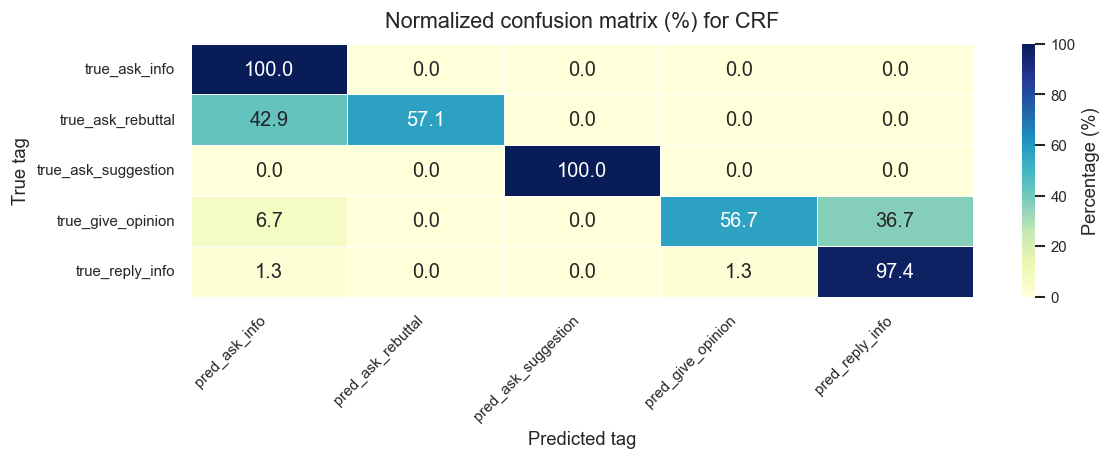

In [23]:
plt.figure(figsize=REPORT_FIGSIZE)

ax = sns.heatmap(
    cm_df,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100
)

style_report_plot(
    ax,
    title="Normalized confusion matrix (%) for CRF",
    xlabel="Predicted tag",
    ylabel="True tag"
)

plt.show()

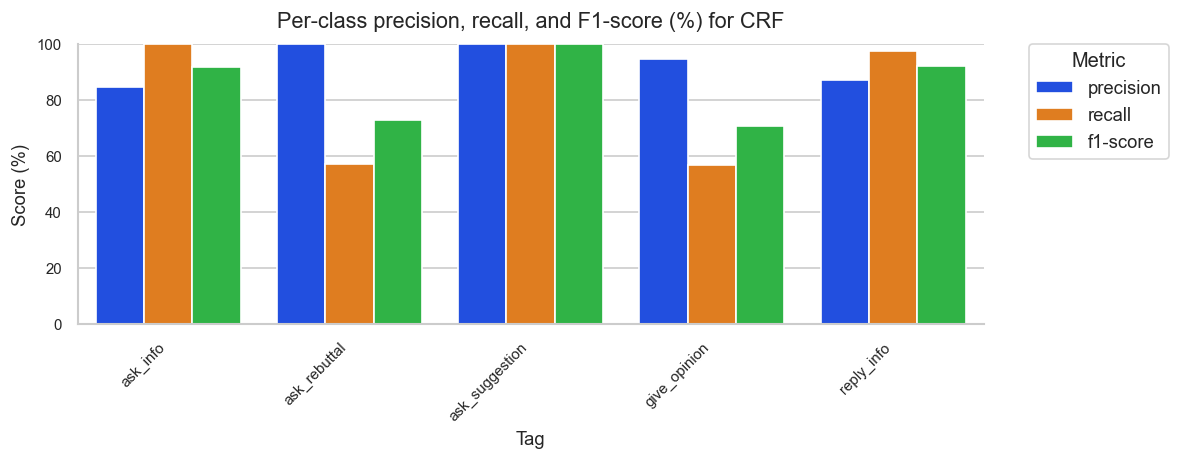

In [24]:
report = classification_report(
    y_test_flat,
    y_pred_flat,
    labels=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

class_metrics_df = (
    report_df
    .loc[labels, ["precision", "recall", "f1-score"]]
    .reset_index()
    .rename(columns={"index": "tag"})
)

class_metrics_long = class_metrics_df.melt(
    id_vars="tag",
    value_vars=["precision", "recall", "f1-score"],
    var_name="Metric",
    value_name="Score"
)

class_metrics_long["Score"] = class_metrics_long["Score"] * 100

custom_palette = "bright"

plt.figure(figsize=REPORT_FIGSIZE)

ax = sns.barplot(
    data=class_metrics_long,
    x="tag",
    y="Score",
    hue="Metric",
    palette=custom_palette
)

ax.set_ylim(0, 100)

ax.legend(
    title="Metric",
    frameon=True,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)

style_report_plot(
    ax,
    title="Per-class precision, recall, and F1-score (%) for CRF",
    xlabel="Tag",
    ylabel="Score (%)"
)

plt.tight_layout()
plt.show()

#### Learned transition weights

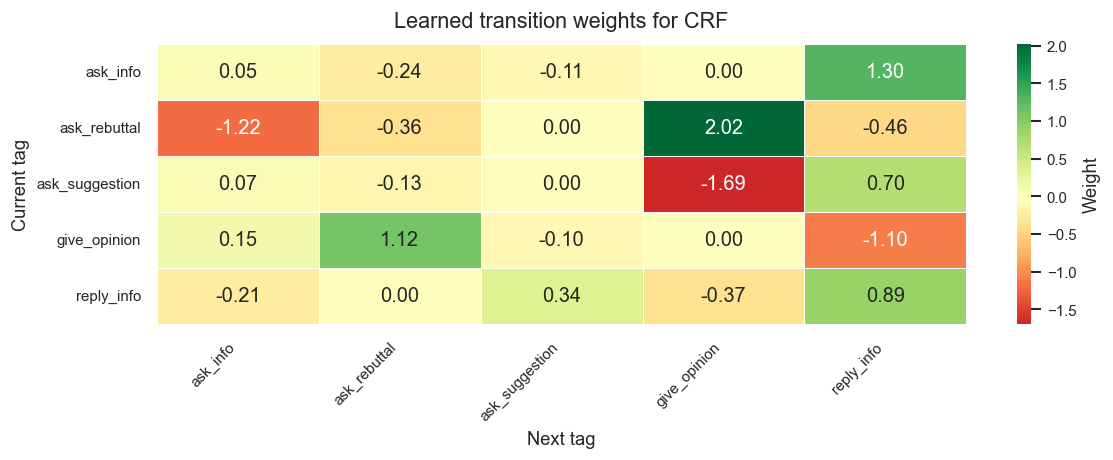

In [25]:
import pandas as pd

transition_weights = {
    (from_tag, to_tag): weight
    for (from_tag, to_tag), weight in crf.transition_features_.items()
}

transition_df = pd.DataFrame(
    [
        {"from_tag": f, "to_tag": t, "weight": w}
        for (f, t), w in transition_weights.items()
    ]
).pivot(index="from_tag", columns="to_tag", values="weight").fillna(0)

plt.figure(figsize=REPORT_FIGSIZE)

ax = sns.heatmap(
    transition_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Weight"},
    center=0
)

style_report_plot(
    ax,
    title="Learned transition weights for CRF",
    xlabel="Next tag",
    ylabel="Current tag"
)

plt.show()

- Note: Unlike HMM's emission/transition probabilities, CRF transition weights are log-linear scores, not probabilities. Positive weights indicate the model encourages that tag transition; negative weights discourage it.

#### Speaker/turn structure influence

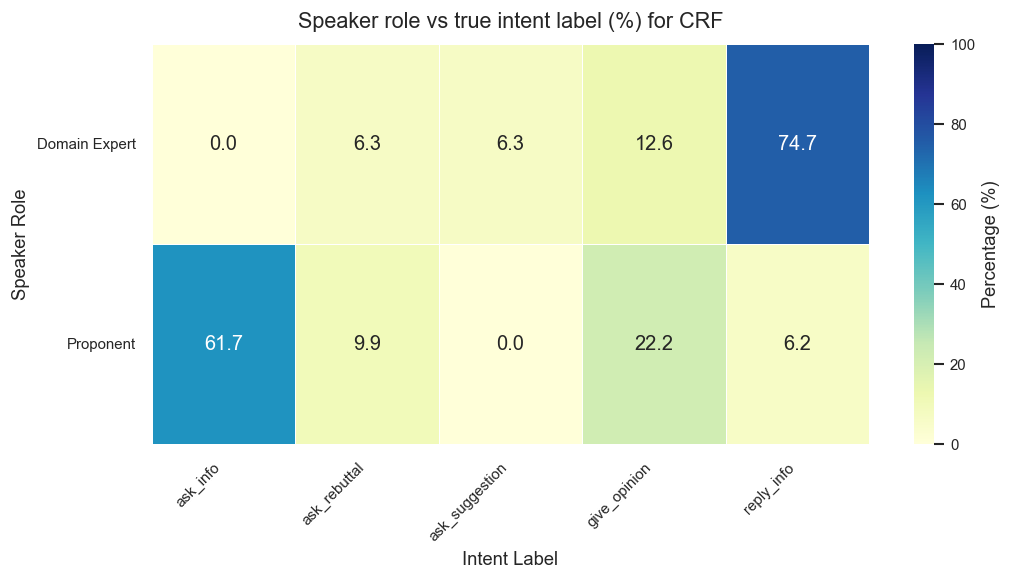

In [26]:
role_tag_table = pd.crosstab(
    results_df["role"],
    results_df["true_tag"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    role_tag_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Speaker role vs true intent label (%) for CRF",
    xlabel="Intent Label",
    ylabel="Speaker Role",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

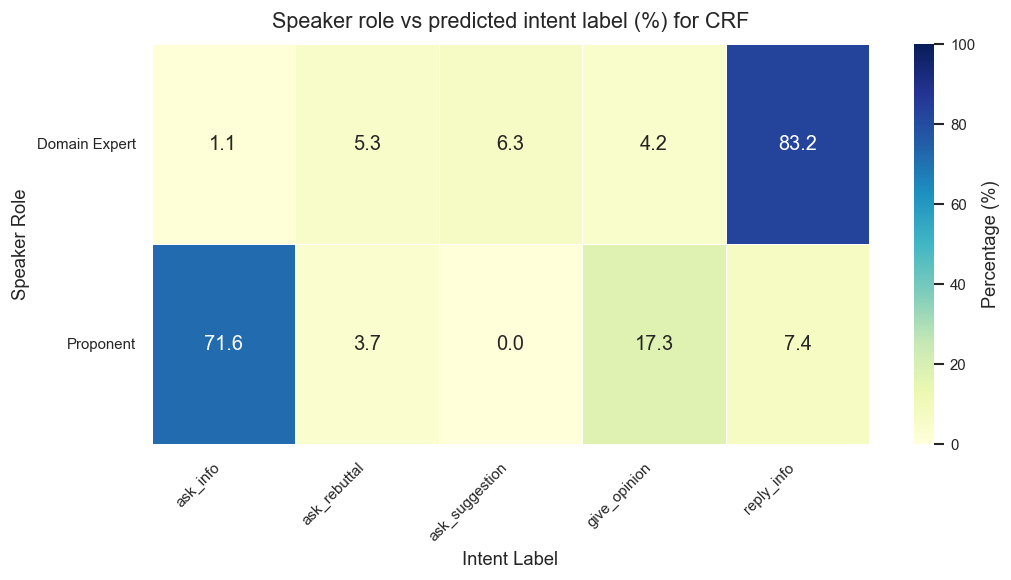

In [29]:
role_tag_table = pd.crosstab(
    results_df["role"],
    results_df["pred_tag"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    role_tag_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Speaker role vs predicted intent label (%) for CRF",
    xlabel="Intent Label",
    ylabel="Speaker Role",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

In [27]:
error_by_role = (
    results_df
    .groupby("role")["correct"]
    .agg(total="count", correct="sum")
    .assign(error_rate=lambda x: (1 - x["correct"] / x["total"]) * 100)
    .reset_index()
    .sort_values("error_rate", ascending=False)
)

print("Error rate by speaker role for CRF:")
error_by_role

Error rate by speaker role for CRF:


,role,total,correct,error_rate
1,Proponent,81,71,12.345679
0,Domain Expert,95,84,11.578947


- Note: The speaker role distribution over intent labels shows whether certain roles are systematically associated with certain intents. The error rate table shows whether the model struggles more with one speaker role than the other, which would indicate that speaker/turn structure is a meaningful signal the model is not fully capturing.